# 08 Activation Price Quality Check

Deep-dive audit for aFRR activation-price realism, volatility, and data quality.

Scope:
- Context merge from ENTSO-E (`load_actual_entsoe`)
- Activation-price diagnostics (AVG vs VWAP)
- Outlier, cap, jump, gap, and frozen-value checks
- 2022 vs 2025 longitudinal quality comparison


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)


## 1) Data Loading & Preparation

Loads:
- `data/raw/entsoe.parquet` (context: `load_actual_entsoe`)
- Best available hourly aFRR dataset from processed files

Primary price under audit:
- `afrr_bid_vwap_activation_price_pos`
- `afrr_bid_vwap_activation_price_neg`

All timestamps are cast to UTC and merged on hourly `timestamp_utc`.

In [2]:
# Resolve project root from notebook location.
ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'src').exists() and (candidate / 'data').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not resolve project root (expected src/ and data/).')

# Candidate processed datasets in priority order.
processed_candidates = [
    ROOT / 'data/processed/cleaned_data.parquet',
    ROOT / 'data/processed/all_data_refined.parquet',
    ROOT / 'data/processed/all_data.parquet',
]

afr_path = next((p for p in processed_candidates if p.exists()), None)
if afr_path is None:
    raise FileNotFoundError('No processed aFRR dataset found in data/processed/.')

entsoe_path = ROOT / 'data/raw/entsoe.parquet'
if not entsoe_path.exists():
    raise FileNotFoundError(f'Missing ENTSO-E file: {entsoe_path}')

print('Using aFRR dataset:', afr_path)
print('Using ENTSO-E file:', entsoe_path)


Using aFRR dataset: /Users/leori/Code/energyTrading/data/processed/cleaned_data.parquet
Using ENTSO-E file: /Users/leori/Code/energyTrading/data/raw/entsoe.parquet


In [3]:
# Load and normalize timestamps.
afr = (
    pl.read_parquet(afr_path)
    .with_columns(pl.col('timestamp_utc').cast(pl.Datetime(time_unit='us', time_zone='UTC'), strict=False))
    .sort('timestamp_utc')
)

entsoe = (
    pl.read_parquet(entsoe_path)
    .with_columns(pl.col('timestamp_utc').cast(pl.Datetime(time_unit='us', time_zone='UTC'), strict=False))
    .sort('timestamp_utc')
)

required = [
    'timestamp_utc',
    'afrr_bid_vwap_activation_price_pos',
    'afrr_bid_vwap_activation_price_neg',
    'afrr_vwap_pos',
    'afrr_vwap_neg',
    'afrr_activated_mw_pos',
    'afrr_activated_mw_neg',
]
missing = [c for c in required if c not in afr.columns]
if missing:
    raise KeyError(f'Missing required aFRR columns: {missing}')

if 'load_actual_entsoe' not in entsoe.columns:
    raise KeyError('load_actual_entsoe not present in entsoe.parquet')

df = (
    afr.select([
        'timestamp_utc',
        pl.col('afrr_bid_vwap_activation_price_pos').cast(pl.Float64),
        pl.col('afrr_bid_vwap_activation_price_neg').cast(pl.Float64),
        pl.col('afrr_vwap_pos').cast(pl.Float64),
        pl.col('afrr_vwap_neg').cast(pl.Float64),
        pl.col('afrr_activated_mw_pos').cast(pl.Float64),
        pl.col('afrr_activated_mw_neg').cast(pl.Float64),
    ])
    .join(
        entsoe.select(['timestamp_utc', pl.col('load_actual_entsoe').cast(pl.Float64)]),
        on='timestamp_utc',
        how='left',
    )
    .with_columns([
        pl.col('timestamp_utc').dt.year().alias('year'),
        pl.col('timestamp_utc').dt.month().alias('month'),
        pl.col('timestamp_utc').dt.hour().alias('hour'),
    ])
    .sort('timestamp_utc')
)

# Long format for direction-wise diagnostics.
df_long = pl.concat([
    df.select([
        'timestamp_utc', 'year', 'month', 'hour', 'load_actual_entsoe',
        pl.lit('POS').alias('direction'),
        pl.col('afrr_bid_vwap_activation_price_pos').alias('price_bid_vwap'),
        pl.col('afrr_vwap_pos').alias('price_vwap'),
        pl.col('afrr_activated_mw_pos').alias('activated_mw'),
    ]),
    df.select([
        'timestamp_utc', 'year', 'month', 'hour', 'load_actual_entsoe',
        pl.lit('NEG').alias('direction'),
        pl.col('afrr_bid_vwap_activation_price_neg').alias('price_bid_vwap'),
        pl.col('afrr_vwap_neg').alias('price_vwap'),
        pl.col('afrr_activated_mw_neg').alias('activated_mw'),
    ]),
]).sort(['direction', 'timestamp_utc'])

print('Rows (wide):', df.height)
print('Rows (long):', df_long.height)
print('Columns (long):', df_long.columns)


Rows (wide): 44568
Rows (long): 89136
Columns (long): ['timestamp_utc', 'year', 'month', 'hour', 'load_actual_entsoe', 'direction', 'price_bid_vwap', 'price_vwap', 'activated_mw']


## 2) Statistical Realism Check

In [4]:
PRICE_COL = 'price_bid_vwap'
VWAP_COL = 'price_vwap'
VOL_COL = 'activated_mw'

outliers_5k = df_long.filter(pl.col(PRICE_COL).abs() > 5000)
outliers_15k = df_long.filter(pl.col(PRICE_COL).abs() > 15000)

print('Outliers |price_bid_vwap| > 5,000 EUR/MWh (by direction):')
display(outliers_5k.group_by('direction').agg(pl.len().alias('n')).sort('direction').to_pandas())

print('Cap violations |price_bid_vwap| > 15,000 EUR/MWh (by direction):')
display(outliers_15k.group_by('direction').agg(pl.len().alias('n')).sort('direction').to_pandas())

# Rolling std and jumps within each direction.
df_long = (
    df_long.sort(['direction', 'timestamp_utc'])
    .with_columns([
        pl.col(PRICE_COL).rolling_std(window_size=24, min_samples=6).over('direction').alias('price_rolling_std_24h'),
        (pl.col(PRICE_COL) - pl.col(PRICE_COL).shift(1).over('direction')).alias('price_diff_1h'),
    ])
    .with_columns(pl.col('price_diff_1h').abs().alias('abs_price_jump_1h'))
)

bouncing = df_long.filter(pl.col('abs_price_jump_1h') > 5000)
print('Price jumps > 5,000 EUR/MWh (by direction):')
display(bouncing.group_by('direction').agg(pl.len().alias('n')).sort('direction').to_pandas())

print('Example outliers:')
display(outliers_5k.select(['timestamp_utc','direction',PRICE_COL,VOL_COL]).head(20).to_pandas())


Outliers |price_bid_vwap| > 5,000 EUR/MWh (by direction):


,direction,n
0,NEG,1306
1,POS,1886


Cap violations |price_bid_vwap| > 15,000 EUR/MWh (by direction):


,direction,n
0,NEG,216
1,POS,404


Price jumps > 5,000 EUR/MWh (by direction):


,direction,n
0,NEG,296
1,POS,372


Example outliers:


,timestamp_utc,direction,price_bid_vwap,activated_mw
0,2020-12-01 03:00:00+00:00,NEG,-29623.858176,9.131
1,2020-12-01 04:00:00+00:00,NEG,-29623.858176,62.839
2,2020-12-01 05:00:00+00:00,NEG,-29623.858176,61.996
3,2020-12-01 06:00:00+00:00,NEG,-29623.858176,32.691
4,2020-12-03 23:00:00+00:00,NEG,-10651.341231,25.462
5,2020-12-04 00:00:00+00:00,NEG,-10651.341231,124.574
6,2020-12-04 01:00:00+00:00,NEG,-10651.341231,75.055
7,2020-12-04 02:00:00+00:00,NEG,-10651.341231,21.039
8,2020-12-04 03:00:00+00:00,NEG,-10189.183969,21.704
9,2020-12-04 04:00:00+00:00,NEG,-10189.183969,22.328


## 3) AVG vs VWAP Diagnostic

In [5]:
# Spread diagnostics: bid_vwap vs reference vwap.
df_long = df_long.with_columns([
    (pl.col(PRICE_COL) - pl.col(VWAP_COL)).abs().alias('error_spread_abs'),
    pl.when(pl.col(VWAP_COL).abs() > 0)
      .then((pl.col(PRICE_COL) - pl.col(VWAP_COL)).abs() / pl.col(VWAP_COL).abs())
      .otherwise(None)
      .alias('error_spread_rel'),
])

spread_summary = (
    df_long.group_by('direction')
    .agg([
        pl.len().alias('n_rows'),
        pl.col('error_spread_abs').mean().alias('mean_abs_spread'),
        pl.col('error_spread_abs').median().alias('median_abs_spread'),
        pl.col('error_spread_abs').max().alias('max_abs_spread'),
        (pl.col('error_spread_rel') * 100).mean().alias('mean_rel_spread_pct'),
        pl.corr('error_spread_abs', VOL_COL).alias('corr_spread_vs_volume'),
    ])
    .sort('direction')
)

print('Spread summary by direction:')
display(spread_summary.to_pandas())

# Hypothesis: high spread correlates with low volume.
hypo = []
for d in ['POS', 'NEG']:
    t = df_long.filter(pl.col('direction') == d)
    q90 = t.select(pl.col('error_spread_abs').quantile(0.9)).item()
    q25v = t.select(pl.col(VOL_COL).quantile(0.25)).item()
    n = t.filter((pl.col('error_spread_abs') >= q90) & (pl.col(VOL_COL) <= q25v)).height
    hypo.append({'direction': d, 'rows_spread_p90_and_vol_p25': n})

display(pd.DataFrame(hypo))


Spread summary by direction:


,direction,n_rows,mean_abs_spread,median_abs_spread,max_abs_spread,mean_rel_spread_pct,corr_spread_vs_volume
0,NEG,44568,0.0,0.0,0.0,0.0,NaN
1,POS,44568,0.0,0.0,0.0,0.0,NaN


,direction,rows_spread_p90_and_vol_p25
0,POS,11143
1,NEG,11143


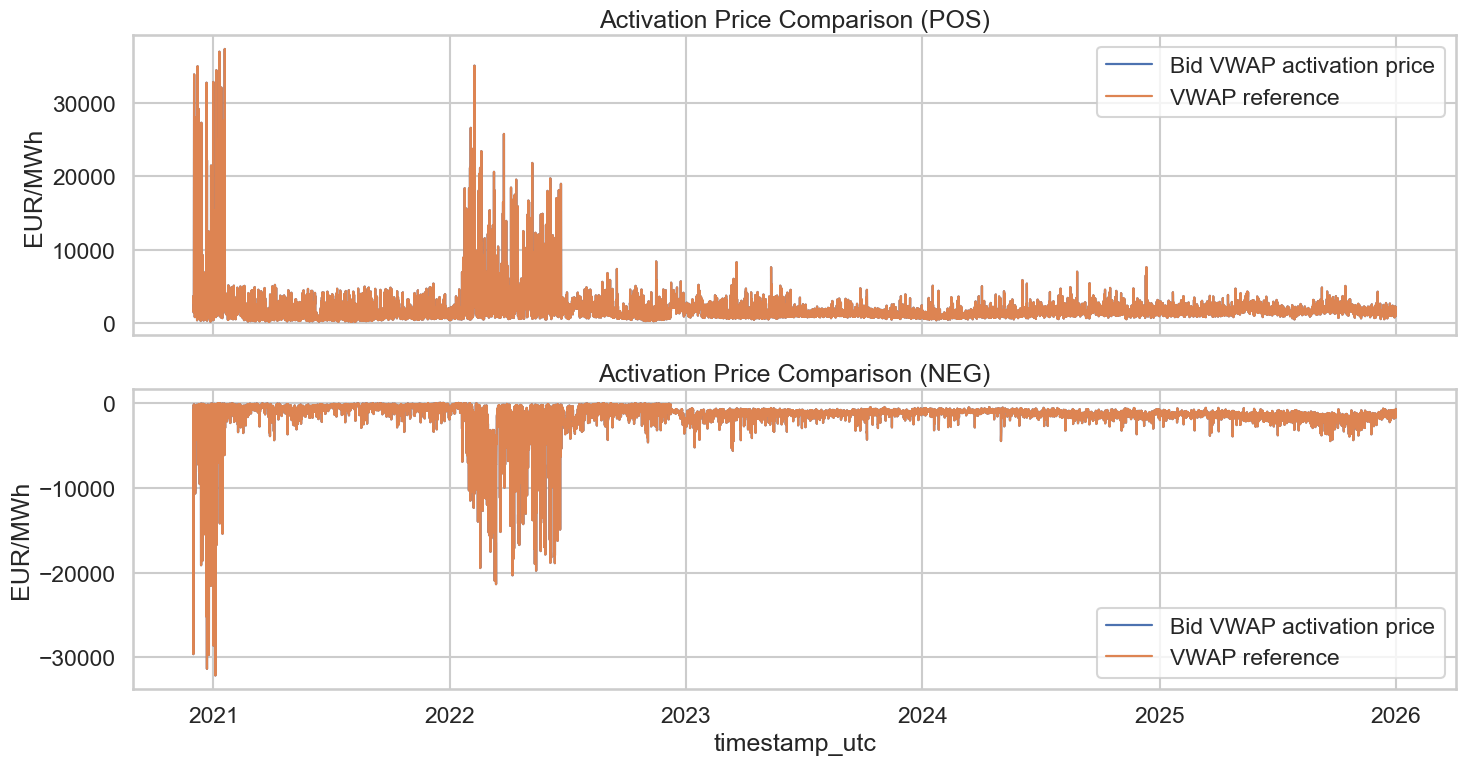

In [6]:
# Plot: bid_vwap vs vwap over time (POS/NEG panels).
plot_pd = (
    df_long.select(['timestamp_utc', 'direction', PRICE_COL, VWAP_COL])
    .drop_nulls()
    .to_pandas()
)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, d in zip(axes, ['POS', 'NEG']):
    ddf = plot_pd[plot_pd['direction'] == d].set_index('timestamp_utc').sort_index()
    ax.plot(ddf.index, ddf[PRICE_COL], label='Bid VWAP activation price', linewidth=1.6)
    ax.plot(ddf.index, ddf[VWAP_COL], label='VWAP reference', linewidth=1.6)
    ax.set_title(f'Activation Price Comparison ({d})')
    ax.set_ylabel('EUR/MWh')
    ax.legend(loc='best')

axes[-1].set_xlabel('timestamp_utc')
plt.tight_layout()
plt.show()


## 4) Longitudinal Quality Audit (2022 vs 2025)

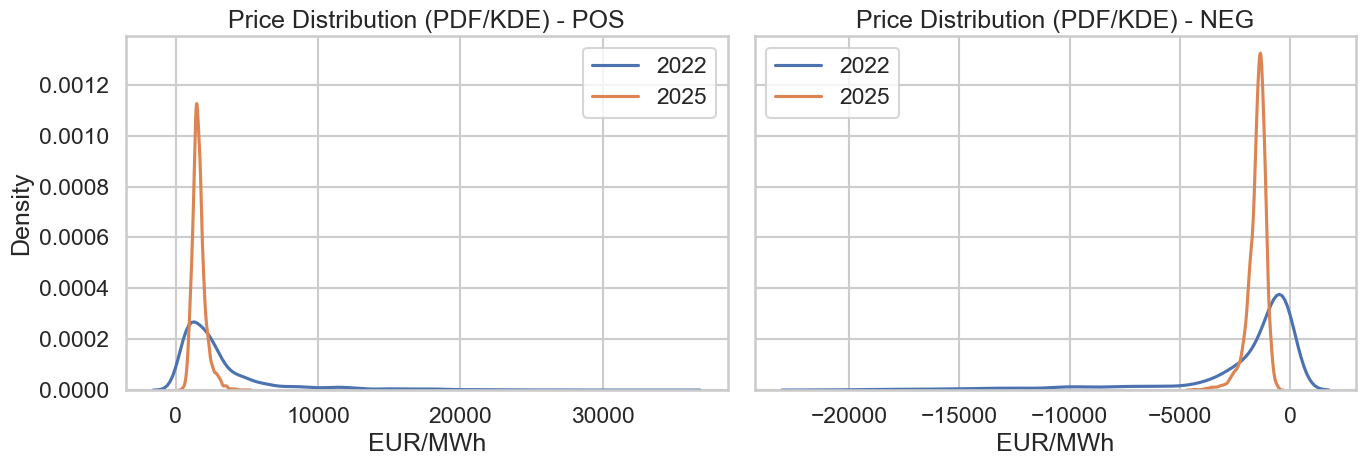

Pearson corr(price_bid_vwap, load_actual_entsoe):


,year,direction,corr_price_vs_load
0,2022,NEG,-0.042816
1,2025,NEG,0.140301
2,2022,POS,0.199001
3,2025,POS,-0.022370


In [7]:
# Distribution comparison for 2022 and 2025 (per direction).
years = [2022, 2025]
sub = df_long.filter(pl.col('year').is_in(years)).select(['year', 'direction', PRICE_COL, 'load_actual_entsoe'])
sub_pd = sub.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, d in zip(axes, ['POS', 'NEG']):
    ddf = sub_pd[sub_pd['direction'] == d]
    for y in years:
        s = ddf.loc[ddf['year'] == y, PRICE_COL].dropna()
        if len(s) > 10:
            sns.kdeplot(s, ax=ax, label=str(y), fill=False)
    ax.set_title(f'Price Distribution (PDF/KDE) - {d}')
    ax.set_xlabel('EUR/MWh')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation with load by year and direction.
corr_tbl = (
    df_long.filter(pl.col('year').is_in(years))
    .group_by(['year', 'direction'])
    .agg(pl.corr(PRICE_COL, 'load_actual_entsoe').alias('corr_price_vs_load'))
    .sort(['direction', 'year'])
)
print('Pearson corr(price_bid_vwap, load_actual_entsoe):')
display(corr_tbl.to_pandas())


In [8]:
# Gap analysis: NaNs and frozen values (>3h) by direction.
na_tbl = (
    df_long.group_by('direction')
    .agg(pl.col(PRICE_COL).is_null().sum().alias('nan_rows'))
    .sort('direction')
)
print('NaN rows in bid_vwap price:')
display(na_tbl.to_pandas())

frozen_report = []
for d in ['POS', 'NEG']:
    p = (
        df_long.filter(pl.col('direction') == d)
        .select(['timestamp_utc', PRICE_COL])
        .to_pandas()
        .sort_values('timestamp_utc')
        .reset_index(drop=True)
    )
    vals = p[PRICE_COL]
    same_as_prev = vals.eq(vals.shift(1))
    run_id = same_as_prev.ne(same_as_prev.shift(1)).cumsum()
    run_len = same_as_prev.groupby(run_id).transform('sum') + 1
    frozen_mask = same_as_prev & (run_len > 3)
    frozen_report.append({'direction': d, 'frozen_rows_gt3h': int(frozen_mask.sum())})

print('Frozen-value rows (>3h same exact value):')
display(pd.DataFrame(frozen_report))


NaN rows in bid_vwap price:


,direction,nan_rows
0,NEG,1
1,POS,1


Frozen-value rows (>3h same exact value):


,direction,frozen_rows_gt3h
0,POS,10212
1,NEG,10212


## 5) Required Visualizations

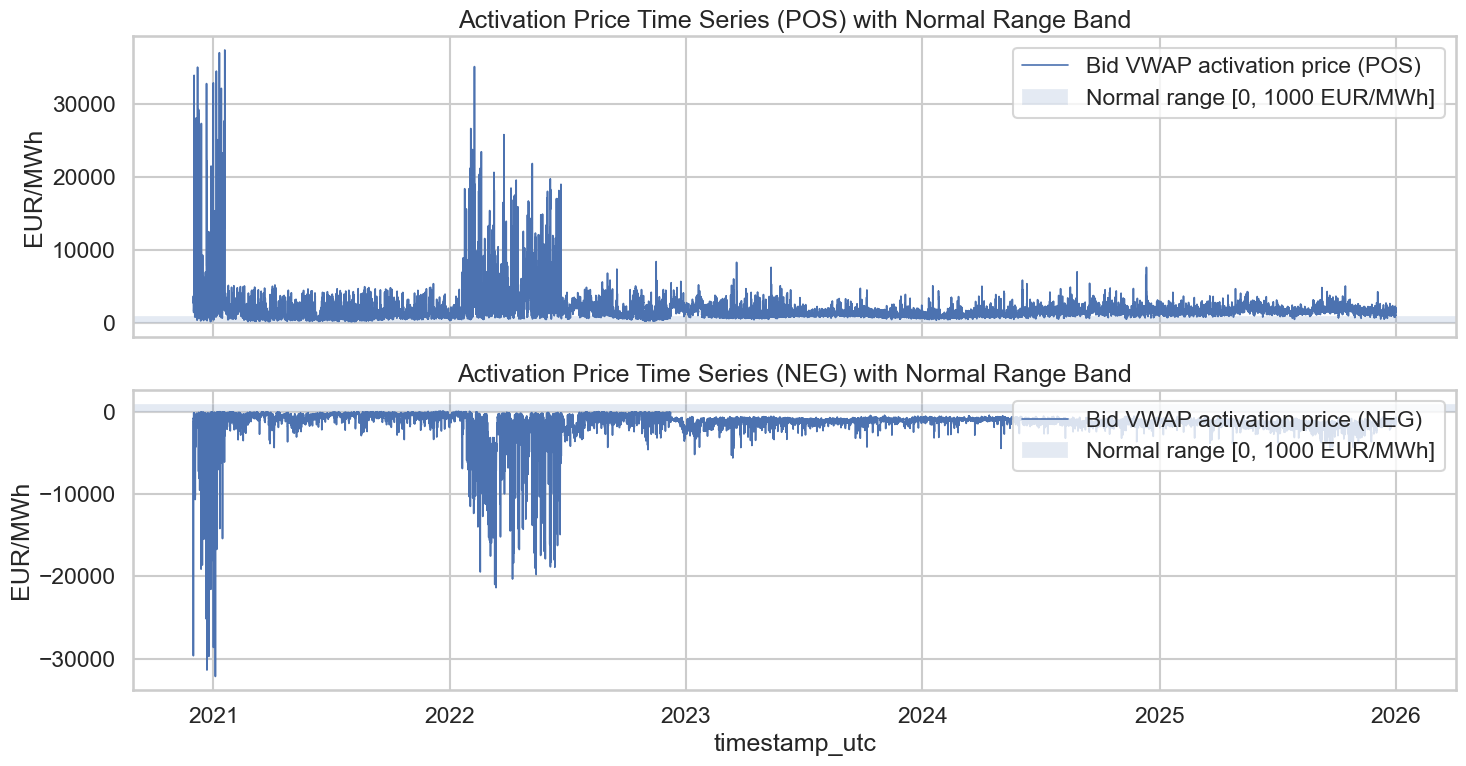

In [9]:
# Plot 1: Time-series with shaded normal range [0, 1000] EUR.
ts_pd = (
    df_long.select(['timestamp_utc', 'direction', PRICE_COL])
    .drop_nulls()
    .to_pandas()
)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, d in zip(axes, ['POS', 'NEG']):
    ddf = ts_pd[ts_pd['direction'] == d].set_index('timestamp_utc').sort_index()
    ax.plot(ddf.index, ddf[PRICE_COL], linewidth=1.2, label=f'Bid VWAP activation price ({d})')
    ax.axhspan(0, 1000, alpha=0.15, label='Normal range [0, 1000 EUR/MWh]')
    ax.set_title(f'Activation Price Time Series ({d}) with Normal Range Band')
    ax.set_ylabel('EUR/MWh')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('timestamp_utc')
plt.tight_layout()
plt.show()


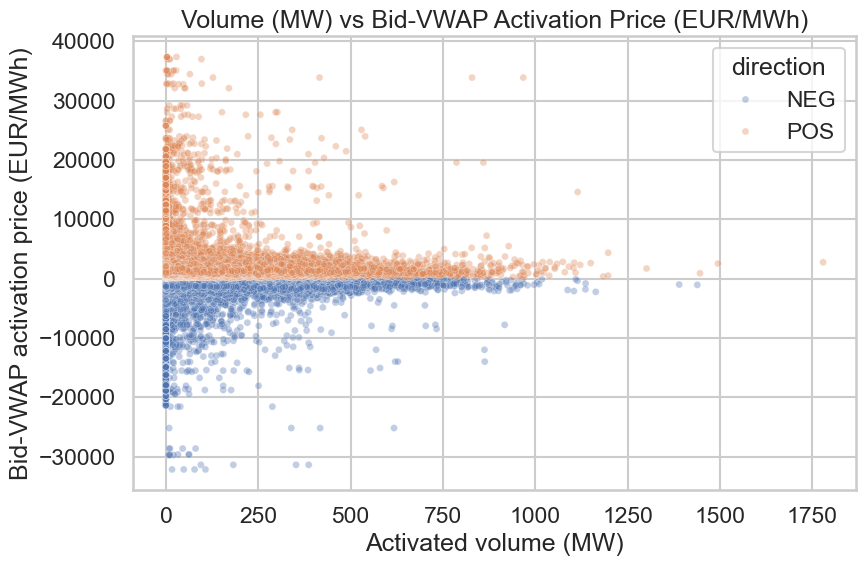

In [10]:
# Plot 2: Scatter volume vs price (Merit-order exhaustion proxy).
sc_pd = df_long.select(['direction', VOL_COL, PRICE_COL]).drop_nulls().to_pandas()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sc_pd, x=VOL_COL, y=PRICE_COL, hue='direction', alpha=0.35, s=25, ax=ax)
ax.set_title('Volume (MW) vs Bid-VWAP Activation Price (EUR/MWh)')
ax.set_xlabel('Activated volume (MW)')
ax.set_ylabel('Bid-VWAP activation price (EUR/MWh)')
plt.tight_layout()
plt.show()


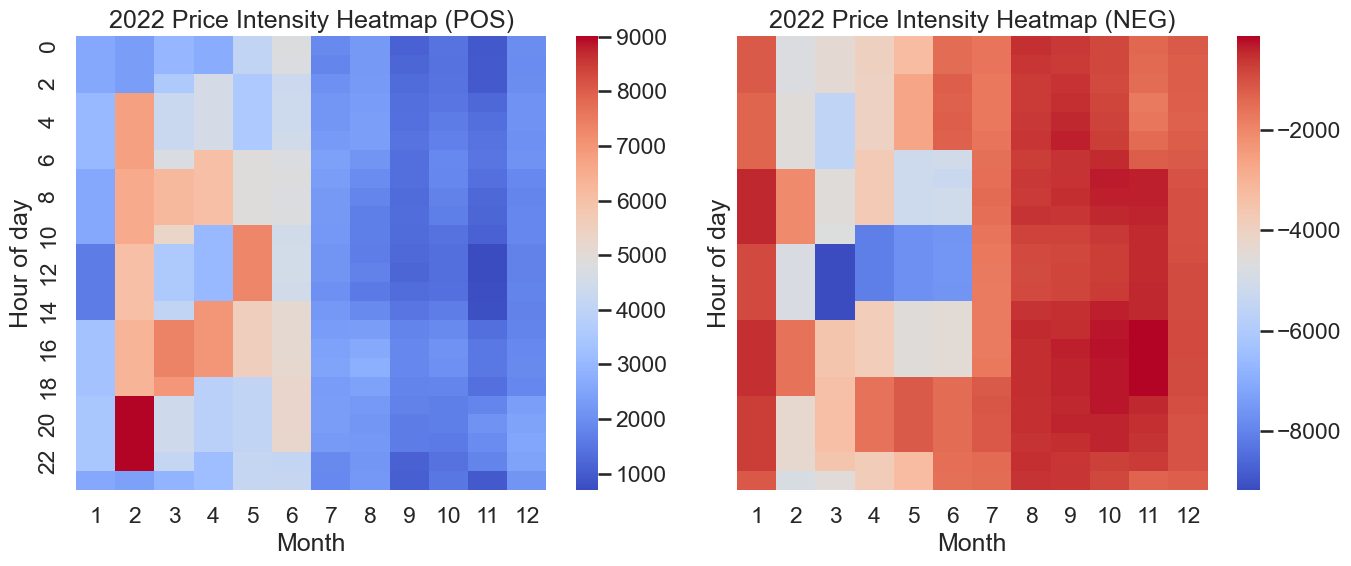

In [11]:
# Plot 3: Heatmap hour-of-day x month for 2022 (POS and NEG).
heat = (
    df_long.filter(pl.col('year') == 2022)
      .group_by(['direction', 'month', 'hour'])
      .agg(pl.col(PRICE_COL).mean().alias('price_mean'))
      .sort(['direction', 'month', 'hour'])
)

heat_pd = heat.to_pandas()
if len(heat_pd) == 0:
    print('No data available for 2022 heatmap.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax, d in zip(axes, ['POS', 'NEG']):
        ddf = heat_pd[heat_pd['direction'] == d]
        pivot = ddf.pivot(index='hour', columns='month', values='price_mean')
        sns.heatmap(pivot, cmap='coolwarm', ax=ax)
        ax.set_title(f'2022 Price Intensity Heatmap ({d})')
        ax.set_xlabel('Month')
        ax.set_ylabel('Hour of day')
    plt.tight_layout()
    plt.show()


## Optional Export: Quality Flags

Uncomment to persist key flagged events for reporting.

```python
# out = ROOT / 'reports' / 'activation_price_quality_flags.csv'
# out.parent.mkdir(parents=True, exist_ok=True)
# bouncing.write_csv(out)
# print('Wrote', out)
```